In [1]:
import numpy as np 
import pandas as pd 
import arviz as az
from scipy import stats 
from scipy.special import gamma as gamma_func
from matplotlib import pyplot as plt

/Users/jaroldeen/Code/stats/stat651/.statvenv/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


This notebook is for developing and testing an MCMC sampler for the cyclones hierarchical model. The fully-developed sampler method can be accessed and called from the sampler.py file.

**Likelihood:**
$$\log{W_i} | \mu_i, \sigma_{b_i}^2 \sim \textrm{Normal}(\mu_i, \sigma_{b_i}^2)$$
$$\mu_i = \vec{x}_i \vec{\beta_{b_i}}^T\$$

**Priors for Latent Parameters:**
$$\sigma_{b}^2 |\alpha, \gamma \sim \textrm{Inverse-Gamma}(\alpha, \textrm{scale}=\gamma)$$
$$\vec{\beta^{(d)}} | \nu_d, \tau_d \sim \textrm{MultivarNormal}(\nu_d \vec{1}, \tau_d^2I_B)$$
$$\tau_d^2 | \lambda_d \sim \textrm{Inverse-Gamma} (a, \textrm{scale}=\lambda_d)$$

**Priors for Hyperparameters:**


I chose Gamma distributions for $\alpha$ and $\gamma$ just based on these parameters having to be positive, but we could choose something else. Using Gamma as a prior for $\gamma$ makes it conditionally conjugate given $\alpha$, which is nice. We can also choose a different prior on $\lambda_d$.

$$\alpha \sim \textrm{Gamma}(y_{\alpha}, \textrm{scale}=z_{\alpha})$$
$$\gamma \sim \textrm{Gamma}(y_{\gamma}, \textrm{scale}=z_{\gamma})$$
$$\vec{\nu} \sim \textrm{MultivarNormal}(\vec{0}, v^2 I_D)$$
$$\lambda_d \sim \textrm{Gamma} (y_{\lambda}, \textrm{scale} = z_{\lambda})$$

Here $a, y_{\alpha}, z_{\alpha}, y_{\gamma}, z_{\gamma}, y_{\lambda}, z_{\lambda},$ and $v$ are all constant values. We can experiment with different hyperprior parameters, but these values will not be modeled. 

**Notes on Notation**
- The index $i \in {1, ..., N}$ denotes cyclone events (e.g. $W_i$ refers to the wind speed of the $i$-th cyclone).
- The index $b \in {1, ..., B}$ denotes ocean basins. The double index $b_i$ denotes the ocean basin associated with the $i$-th cyclone. 
- The index $d \in {1, ..., D}$ denotes predictor variables. 
- The matrix X has $N$ rows and $D$ columns, and contains predictors for each cyclone. The row vector $\vec{x}_i$ denotes the predictors for the $i$-th cyclone.
- The matrix $\beta$ has $B$ rows and $D$ columns. The row vector $\vec{\beta_{b_i}}$ has length $D$ and denotes the regression parameters for the ocean basin associated with the $i$-th cyclone. The column vector $\vec{\beta^{(d)}}$ has length $B$ and denotes the regression parameters for the $d$-th predictor across all ocean basins. 

In [ ]:
class CycloneSampler:

    def __init__(self, W, X, basins, a, y_alpha, z_alpha, y_gamma, z_gamma, y_lam, z_lam, v2, B):
        ''' Constructor. Accepts data and hyperparameters and saves these as class attributes.

            Parameters:
                w (ndarray) : log of Maximum Sustained Wind Speed observations for hours 12-60 of each cyclone 
                X (ndarray) : design matrix, contains predictor variables for each observation 
                basins (ndarray) : array of ints/indices indicating the ocean basin for each observation
                y_alpha (float) : shape parameter for gamma hyperprior (must be positive)
                z_alpha (float) : scale parameter for gamma hyperprior (must be positive)
                y_gamma (float) : shape parameter for gamma hyperprior (must be positive)
                z_gamma (float) : scale parameter for gamma hyperprior (must be positive)
                kappa (float) : variance parameter for multivariate-normal hyperprior (must be positive)
                omega (float) : scale parameter for half-Cauchy hyperprior (must be positive)
                B (int) : the number of unique ocean basins to be modeled
        '''

        # save data as attributes
        self.W = W
        self.X = X
        self.basins = basins

        # save hyperparameters as attributes
        self.a = a
        self.y_alpha = y_alpha 
        self.z_alpha = z_alpha 
        self.y_gamma = y_gamma 
        self.z_gamma = z_gamma 
        self.y_lam = y_lam 
        self.z_lam = z_lam
        self.v2 = v2 

        # save model dimensions as attributes
        self.N, self.D = X.shape 
        self.B = B

        # initialize the current state attribute (this needs to be set with starting values in the sampler)
        self.curr_state = []

        # counter for acceptance rates of M-H sampler
        self.alpha_accept_count = 0
    

    def _draw_sig2(self):
        ''' Draw from the full conditional posterior distribution for the sigma_b^2's.

            Parameters:
                curr_state (list) : a list containing the current values of all model parameters 
            Returns: 
                new_sig2 (ndarray) : an array of length B containing a new draw for variance in each ocean basin
        '''
        curr_sig2, curr_Beta, curr_tau2, curr_alpha, curr_gamma, curr_nu, curr_lam = self.curr_state 
        all_mu = np.array([self.X[i] @ curr_Beta[self.basins[i]] for i in range(self.N)])

        # put this check here just in case 
        if len(curr_sig2) != self.B:
            raise ValueError("Number of sigmas should match number of basins!!")
        
        new_sig2 = np.empty_like(curr_sig2)
        for i in range(self.B):
            
            # extract data/sufficient stats
            basin_idx = self.basins == i 
            basin_mu = all_mu[basin_idx]
            basin_W = self.W[basin_idx]
            N_b = np.sum(basin_idx)
            
            # draw from full conditional
            new_sig2[i] = stats.invgamma.rvs(
                a = curr_alpha + N_b / 2.,
                scale = curr_gamma + np.sum((basin_W - basin_mu)**2) / 2.
            )
    
        # implement sampler!
        # new_sig2 = list()
        # for i in range(len(curr_sig2)):
        #     basin_w = self.w[self.basins == i]
        #     basin_x = self.X[self.basins == i]
        #     N_b = len(basin_data)
        #     mu = basin_x @ basin_w.T
        #     sum_vec = (basin_w - mu)**2
        #     sum_scalar = sum_vec.sum()
        #     new_sig2.append(stats.invgamma.rvs(curr_alpha + N_b/2, 1/(-curr_gamma + 1/2 * sum_scalar)))

        # new_sig2 = np.array(new_sig2)
        return new_sig2
    

    def _draw_Beta(self):
        ''' Draw from the full conditional posterior distribution for the Beta matrix.

            Parameters:
                curr_state (list) : a list containing the current values of all model parameters 
            Returns: 
                new_Beta (ndarray) : a BxD matrix containing a new draw for regression parameters in each ocean basin
        '''
        curr_sig2, curr_Beta, curr_tau2, curr_alpha, curr_gamma, curr_nu, curr_lam = self.curr_state 

        # these are just placeholders. these need to be tuned
        MIN_FEASIBLE_BETA = -5
        MAX_FEASIBLE_BETA = 5
        res = 300

        N, B, D = self.N, self.B, self.D
        new_Beta = curr_Beta

        for b in range(B):
            basin_W = self.W[self.basins == b]
            basin_X = self.X[self.basins == b, :]
            basin_log_likelihood_func = lambda beta_vect: -1/(2*curr_sig2[b])*np.sum((basin_W - basin_X@beta_vect)**2)
            def log_likelihood(beta_d, d):
                    beta_vect = new_Beta[b, :].copy()
                    beta_vect[d] = beta_d
                    return basin_log_likelihood_func(beta_vect) - (1/(2*curr_tau2[d]))*((beta_d - curr_nu[d])**2)
            for d in range(D):
                possible_vals = np.linspace(MIN_FEASIBLE_BETA, MAX_FEASIBLE_BETA, res)
                log_likelihoods = np.array([log_likelihood(val, d) for val in possible_vals])
                log_likelihoods -= np.max(log_likelihoods) 
                likelihoods = np.exp(log_likelihoods)
                cdf_vect = np.cumsum(likelihoods) / np.sum(likelihoods) 
                decision_draw = np.random.random()
                possible_vals = possible_vals[cdf_vect > decision_draw]
                new_Beta[b, d] = possible_vals[0]
        return new_Beta
    
    
    def _draw_tau2(self):
        ''' Draw from the full conditional posterior distribution for the tau_d's.

            Parameters:
                curr_state (list) : a list containing the current values of all model parameters 
            Returns: 
                new_tau2 (ndarray) : an array of length D containing a new draw for variance of each regression parameter
        '''
        curr_sig2, curr_Beta, curr_tau2, curr_alpha, curr_gamma, curr_nu, curr_lam = self.curr_state 
    
        new_tau2 = np.empty_like(curr_tau2)
        for i in range(self.D):
            nu_d = curr_nu[i]
            # beta_row = curr_Beta[i, :]              # should be a column of Beta, not a row
            beta_col = curr_Beta[:, i]
            # sanity check 
            if len(beta_col) != self.B: raise ValueError("Beta column is the wrong shape!")

            # sum_vec = (beta_row - nu_d)**2
            sum_vec = (beta_col - nu_d)**2
            sum_scalar = sum_vec.sum()
            new_tau2[i] = stats.invgamma.rvs(a=self.a + self.B/2., scale=curr_lam[i] + sum_scalar / 2.)

        return new_tau2   
    
    
    def _draw_alpha(self):
        ''' Draw from the full conditional posterior distribution for alpha.

            Parameters:
                curr_state (list) : a list containing the current values of all model parameters 
            Returns: 
                new_alpha (float) : a new draw for the alpha hyperparameter
        '''
        curr_sig2, curr_Beta, curr_tau2, curr_alpha, curr_gamma, curr_nu, curr_lam = self.curr_state 

        def _alpha_log_pdf(input):
            if input > 0.:
                return (
                    self.B * np.log(curr_gamma**input / gamma_func(input)) + 
                    (-input - 1.) * np.sum(np.log(curr_sig2)) + 
                    (self.y_alpha - 1.) * np.log(input) - 
                    (input / self.z_alpha)
                )
            else: return -np.inf
    
        # METROPOLIS-HASTINGS SAMPLER
        # if this doesn't work or takes too much effort to tune, we can try a griddy sampler, but that seems inefficient
        # proposal distribution is normal centered at the current alpha with a generous variance

        # draw from the proposal
        prop_std = 2
        prop_alpha = stats.norm.rvs(loc=curr_alpha, scale=prop_std)
        
        # compute acceptance probability
        accept_prob = np.exp(
            (_alpha_log_pdf(prop_alpha) + stats.norm.logpdf(x=curr_alpha, loc=prop_alpha, scale=prop_std)) - 
            (_alpha_log_pdf(curr_alpha) + stats.norm.logpdf(x=prop_alpha, loc=curr_alpha, scale=prop_std))
        )

        # decide whether to accept or reject 
        if stats.binom.rvs(n=1, p=min(1., accept_prob)):
            self.alpha_accept_count += 1
            new_alpha = prop_alpha 
        else:
            new_alpha = curr_alpha 

        return new_alpha


    def _draw_gamma(self):
        ''' Draw from the full conditional posterior distribution for gamma.

            Parameters:
                curr_state (list) : a list containing the current values of all model parameters 
            Returns: 
                new_gamma (float) : a new draw for the gamma hyperparameter
        '''
        curr_sig2, curr_Beta, curr_tau2, curr_alpha, curr_gamma, curr_nu, curr_lam = self.curr_state 
    
        # new_gamma = stats.gamma(curr_alpha * self.B, 1/(((curr_sig2)**(-1)).sum() + 1/self.z_gamma))        # missing addition of y_gamma
        new_gamma = stats.gamma.rvs(
            a = curr_alpha * self.B + self.y_gamma,
            scale = 1. / (np.sum(1./curr_sig2) + 1./self.z_gamma)
        )

        return new_gamma


    def _draw_nu(self):
        ''' Draw from the full conditional posterior distribution for nu.

            Parameters:
                curr_state (list) : a list containing the current values of all model parameters 
            Returns: 
                new_nu (array) : a vector of length D containing new draws of nu for each predictor
        '''
        curr_sig2, curr_Beta, curr_tau2, curr_alpha, curr_gamma, curr_nu, curr_lam = self.curr_state
        

        new_nu = np.empty_like(curr_nu)
        for i in range(self.D):
            # covar = (1/self.kappa + self.D/curr_tau2)**(-1)     # should be B instead of D, kappa has been changed to v, tau2 should be indexed
            covar = (1./self.v2 + self.B/curr_tau2[i])**(-1.)
            # mu = curr_Beta[:, i].sum()/curr_tau2                # tau2 should be indexed
            mu = np.sum(curr_Beta[:, i]) / curr_tau2[i]
            new_nu[i] = stats.norm.rvs(loc=covar * mu, scale=np.sqrt(covar))

        return new_nu
    

    def _draw_lam(self):
        ''' Draw from the full conditional posterior distribution for the lambda_d's.

            Parameters:
                curr_state (list) : a list containing the current values of all model parameters 
            Returns: 
                new_lam (ndarray) : a vector of length D containing new draws for lambda for each predictor
        '''
        curr_sig2, curr_Beta, curr_tau2, curr_alpha, curr_gamma, curr_nu, curr_lam = self.curr_state 
    
        new_lam = np.empty_like(curr_lam)
        for i in range(self.D):
            # new_lam[i] = stats.gamma.rvs(self.y_alpha + self.a, 1/(1/curr_tau2[i] + 1/self.z_lambda))        # should use y_lam and z_lam
            new_lam[i] = stats.gamma.rvs(
                a = self.y_lam + self.a,
                scale = 1./(1./curr_tau2[i] + 1/self.z_lam)
            )

        return new_lam
    
    
    def _sweep(self):
        ''' Perform one full sweep of MCMC (sample from all full conditionals).
            Updates the self.curr_state attribute in place with the new draws
        '''

        # draw from the complete conditional for sig2 
        self.curr_state[0] = self._draw_sig2()

        # draw from the complete conditional for Beta 
        self.curr_state[1] = self._draw_Beta()

        # draw from the complete conditional for tau 
        self.curr_state[2] = self._draw_tau2()

        # draw from the complete conditional for alpha
        self.curr_state[3] = self._draw_alpha()

        # draw from the complete conditional for gamma
        self.curr_state[4] = self._draw_gamma()

        # draw from the complete conditional for nu
        self.curr_state[5] = self._draw_nu()

        # draw from the complete conditional for lambda
        self.curr_state[6] = self._draw_lam()
    

    def _log_likelihood(self):
        ''' Compute and return the log-likelihood of all of the cyclone observations, 
            given the curr_state parameters.  

            Returns:
                (float) : the log-likelihood
        '''

        # extract necessary parameters for likelihood computation 
        curr_sig2, curr_Beta, curr_tau2, curr_alpha, curr_gamma, curr_nu, curr_lam = self.curr_state 
        all_sig2 = np.array([curr_sig2[self.basins[i]] for i in range(self.N)])
        all_mu = np.array([self.X[i] @ curr_Beta[self.basins[i]] for i in range(self.N)])

        # compute and return likelihood
        return (
            (-self.N/2.) * np.log(2.*np.pi) -
            np.sum(np.log(all_sig2)) / 2. - 
            np.sum((1./all_sig2) * (self.W - all_mu)**2.) / 2. 
        )
    

    def _log_posterior_probs(self):
        ''' This function should evaluate the posterior probability of a parameter draw.
        '''
        raise NotImplementedError("Posterior probability computation not implemented!")


    def sample(self, n_samples, init_state=None):
        ''' Use MCMC to draw many samples from the cyclone model posterior. 

            Parameters: 
                n_samples (int) : number of posterior samples to draw
            Returns:
                NOT SURE WHAT THIS WILL RETURN YET, COME BACK TO THIS
                It will probably save all the draws as attributes rather than returning
        '''

        # initialize matrices to store posterior parameter draws 
        self.sig2_draws = np.empty((n_samples, self.B))
        self.Beta_draws = np.empty((n_samples, self.B, self.D))
        self.tau2_draws = np.empty((n_samples, self.D))
        self.alpha_draws = np.empty(n_samples)
        self.gamma_draws = np.empty(n_samples)
        self.nu_draws = np.empty((n_samples, self.D))
        self.lam_draws = np.empty((n_samples, self.D))
        
        # initalize arrays to store log-likelihood for each draw
        self.log_like = np.empty(n_samples)

        # TO DO: initialize an array to store log posterior probability for each draw

        # TO DO: set an starting value for the current state
        if init_state is None: 
            raise ValueError("Random initialization of current state not yet implemented! Please provide an initial state for the chain!")
        else: self.curr_state = init_state

        # MCMC loop 
        for k in range(n_samples):

            # get a new posterior draw for all parameters 
            self._sweep()

            # save the draws for each parameter 
            self.sig2_draws[k] = self.curr_state[0]
            self.Beta_draws[k] = self.curr_state[1]
            self.tau2_draws[k] = self.curr_state[2]
            self.alpha_draws[k] = self.curr_state[3]
            self.gamma_draws[k] = self.curr_state[4]
            self.nu_draws[k] = self.curr_state[5] 
            self.lam_draws[k] = self.curr_state[6]

            # compute and store log-likelihood for current draw
            self.log_like[k] = self._log_likelihood()

            # TO DO: compute and store log posterior probability for current parameters

    def partial_sample(self, n_samples, params_to_include, init_state=None, start_with_true_vals=True):
        ''' Use MCMC to draw many samples from the cyclone model posterior. 

            Parameters: 
                n_samples (int) : number of posterior samples to draw
            Returns:
                NOT SURE WHAT THIS WILL RETURN YET, COME BACK TO THIS
                It will probably save all the draws as attributes rather than returning
        '''

        # initialize matrices to store posterior parameter draws 
        self.sig2_draws = np.empty((n_samples, self.B))
        self.Beta_draws = np.empty((n_samples, self.B, self.D))
        self.tau2_draws = np.empty((n_samples, self.D))
        self.alpha_draws = np.empty(n_samples)
        self.gamma_draws = np.empty(n_samples)
        self.nu_draws = np.empty((n_samples, self.D))
        self.lam_draws = np.empty((n_samples, self.D))
        
        # initalize arrays to store log-likelihood for each draw
        self.log_like = np.empty(n_samples)

        # TO DO: initialize an array to store log posterior probability for each draw

        # TO DO: set an starting value for the current state
        if init_state is None: 
            raise ValueError("Random initialization of current state not yet implemented! Please provide an initial state for the chain!")
        else:
            self.curr_state = init_state
            if not start_with_true_vals:
                raise NotImplemented("Haven't made this part yet, but it should change the start values of the ones you want to test")
        # MCMC loop 
        for k in range(n_samples):

            # get a new posterior draw for all parameters 
            if "sig2" in params_to_include:
                # draw from the complete conditional for sig2 
                self.curr_state[0] = self._draw_sig2()

            if "Beta" in params_to_include: 
                # draw from the complete conditional for Beta 
                self.curr_state[1] = self._draw_Beta()

            if "tau2" in params_to_include: 
                # draw from the complete conditional for tau 
                self.curr_state[2] = self._draw_tau2()
            
            if "alpha" in params_to_include: 
                # draw from the complete conditional for alpha
                self.curr_state[3] = self._draw_alpha()

            if "gamma" in params_to_include: 
                # draw from the complete conditional for gamma
                self.curr_state[4] = self._draw_gamma()

            if "nu" in params_to_include: 
                # draw from the complete conditional for nu
                self.curr_state[5] = self._draw_nu()
            
            if "lam" in params_to_include: 
                # draw from the complete conditional for lambda
                self.curr_state[6] = self._draw_lam()

            # save the draws for each parameter 
            self.sig2_draws[k] = self.curr_state[0]
            self.Beta_draws[k] = self.curr_state[1]
            self.tau2_draws[k] = self.curr_state[2]
            self.alpha_draws[k] = self.curr_state[3]
            self.gamma_draws[k] = self.curr_state[4]
            self.nu_draws[k] = self.curr_state[5] 
            self.lam_draws[k] = self.curr_state[6]

            # compute and store log-likelihood for current draw
            self.log_like[k] = self._log_likelihood()

In [ ]:
class CycloneDataSimulator:
    ''' Generate simulated cyclone data according to the specified hierarichical model. 
    '''

    def __init__(self, B, a, y_alpha, z_alpha, y_gamma, z_gamma, v2, y_lam, z_lam, X=None, basins=None):
        ''' Constructor. Accepts necessary parameters to specify the model's hyperpriors. 

            Parameters:
                B (int) : number of ocean basins to be modeled
                y_alpha (float) : shape parameter for gamma hyperprior (must be positive)
                z_alpha (float) : scale parameter for gamma hyperprior (must be positive)
                y_gamma (float) : shape parameter for gamma hyperprior (must be positive)
                z_gamma (float) : scale parameter for gamma hyperprior (must be positive)
                kappa2 (float) : variance parameter for multivariate-normal hyperprior (must be positive)
                omega (float) : scale parameter for half-Cauchy hyperprior (must be positive)
                X (ndarray or None) : matrix of observed predictors 
                    **if no X is provided, generate_X() must be called to simulate predictors prior to sampling
                basins (ndarray) : array of ints/indices indicating the ocean basin for each observation
                    ** if not provided, basins will be specified during sampling and will assume 
                        an even number of samples from each basin 
        '''
        # save data inputs as class attributes 
        self.B = B 
        self.X = X 
        if X is not None: self.N_sim, self.D = X.shape
        else: self.N_sim, self.D = None, None
        self.basins = basins

        # save hyperparameters as class attributes 
        self.a = a
        self.y_alpha = y_alpha 
        self.z_alpha = z_alpha 
        self.y_gamma = y_gamma 
        self.z_gamma = z_gamma 
        self.v2 = v2 
        self.y_lam = y_lam 
        self.z_lam = z_lam


    def _assign_basins(self, N_sim):      
        ''' Create an array of integers/indices indicating the ocean basin for each associated observation. Assume roughly the same 
            number of cyclone observations from each ocean basin. Save this array as an attribute. 

            Parameters:
                N_sim (int) : desired number of simulated cyclone observations 
        '''
        # generate roughly evenly distributed basin assignments for observations
        # this is an efficient way to do this according to Gemini
        self.basins = np.arange(N_sim) * self.B // N_sim 


    def generate_X(self, N_sim):
        ''' Generate data for predictors. Does not return anything, but sets the class attribute X with a matrix simulated 
            data for the following features:
                - El Nino Index (between -2 to 2??)
                - Maximum Sustained Wind Speed (log-scale) over the first 12 hours of the cyclone
                - Minimum Sea Pressure over the first 12 hours of the cyclone
                - Wind Speed Gradient over the most recent 6 hours of the cyclone
                - Potential Intensity over the first 12 hours of the cyclone (same units as wind speed)

            Parameters: 
                N_sim (int) : desired number of simulated observations
        '''
        # we assume that if X isn't specified, the basins aren't either. Call the helper function to assign basins for each observation 
        self._assign_basins(N_sim)

        # generate El Nino index data 
        # normally between -2 and 2, with extreme values up to -3 or 3
        # use a normal distribution centered at zero with std=1
        el_nino_sims = stats.norm.rvs(loc=0., scale=1., size=N_sim)
        
        # generate max sustained wind speed 
        # normally between 25 and 65 knots 
        max_wind_sims = np.log(stats.norm.rvs(loc=40., scale=5., size=N_sim))       # log scale!!
        
        # generate minimum sea pressure
        # generally between 640 and 1000 hPa
        min_sea_press_sims = np.log(stats.norm.rvs(loc=990, scale=20., size=N_sim)) # log scale!!

        # generate wind speed gradient
        # subtract normals, one higher than the other
        wind_grad_sims = np.log(stats.norm.rvs(loc=40., scale=5., size=N_sim)) - np.log(stats.norm.rvs(loc=30, scale=5., size=N_sim))

        # Potential Intensity
        # same as max wind speed, just with a higher mean
        POT_sims = np.log(stats.norm.rvs(loc=100., scale=20., size=N_sim))       # log scale!!

        # stack data into a design matrix
        X = np.vstack([el_nino_sims, max_wind_sims, min_sea_press_sims, wind_grad_sims, POT_sims]).T

        self.X = X
        self.N_sim, self.D = X.shape

    
    def simulate(self):
        ''' Generate observations of Maximum Sustained Wind Speed over hours 12-60 of a cyclone, given predictors 
            and the described Bayesian hierarhical model.

            Returns: 
                W (ndarray) : array of length N_sim containing simulated observations of Maximum Sustained Wind Speed (log-scale)
        '''
        # check that all of the necessary model parameters are defined 
        if self.X is None or self.N_sim is None or self.basins is None or self.D is None: 
            raise ValueError("At least one of X, N_sim, and basins is not specified!")

        # draw from hyperpriors, save these as attributes
        self.alpha = stats.gamma.rvs(a=self.y_alpha, scale=self.z_alpha)
        self.gamma = stats.gamma.rvs(a=self.y_gamma, scale=self.z_gamma)
        self.nu = stats.multivariate_normal.rvs(mean=np.zeros(self.D), cov=(self.v2 * np.eye(self.D)))
        # self.lam = stats.halfcauchy.rvs(loc=0., scale=self.omega, size=self.D)
        self.lam = stats.gamma.rvs(a=self.y_lam, scale=self.z_lam, size=self.D)

        # draw from hierarchical priors, save these as attributes 
        self.sig2 = stats.invgamma.rvs(a=self.alpha, scale=self.gamma, size=self.B)
        # self.tau = stats.halfcauchy.rvs(loc=0., scale=self.lam)
        self.tau2 = stats.invgamma.rvs(a=self.a, scale=self.lam)
        self.Beta = np.vstack(
            [stats.multivariate_normal.rvs(
                mean = self.nu[d] * np.ones(self.B),
                cov = self.tau2[d] * np.eye(self.B),
            ) for d in range(self.D)]
        ).T

        # expand mu and sig2 by observation so that the process can be vectorized
        all_sig2 = np.array([self.sig2[self.basins[i]] for i in range(self.N_sim)])
        all_mu = np.array([self.X[i] @ self.Beta[self.basins[i]] for i in range(self.N_sim)])

        # draw observations from the likelihood 
        self.W = stats.norm.rvs(loc=all_mu, scale=np.sqrt(all_sig2))

        return self.W

In [109]:
# hyperprior parameters
a = 3
y_alpha = 2
z_alpha = 1
y_gamma = 2
z_gamma = 0.2
v2 = 5
y_lam = 2
z_lam = 1

# test the data simulator 
DataSimulator = CycloneDataSimulator(
    B = 2,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)

# generate X (design matrix)
DataSimulator.generate_X(N_sim=30)
X = DataSimulator.X
basins = DataSimulator.basins

# print(X)
# print(basins)

# sample wind speeds
W_sim = DataSimulator.simulate()
# print(W_sim)
# print(np.exp(W_sim))

real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

real_params_dict = {"sig2": real_params[0], "Beta": real_params[1], "tau2": real_params[2], "alpha": real_params[3], "gamma": real_params[4], "nu": real_params[5], "lam": real_params[6]}
W_sim

array([ 0.50443241,  2.64367531,  1.1579261 , -0.78742862,  1.30747355,
       -1.93450994, -0.50229878,  0.64562193, -3.27791306, -0.45943236,
        5.4419445 , -0.75808542,  2.90970185, -0.28554568,  2.55644994,
        1.59019099, -1.83750706, -4.5510897 , -3.88659329, -6.48171918,
       -5.07838219, -4.01776834, -5.16490967, -3.35783307, -3.37266675,
       -5.62123351, -3.84180312, -3.82781833, -2.63002961, -1.23997814])

In [110]:
def comparison_table(sampler, real_params_dict, params_to_include=["alpha", "gamma", "Beta", "lam", "nu", "tau2", "sig2"], burnin=0):
    table = {}
    params = params_to_include
    for param in params:
        sampler_result = np.mean(getattr(sampler, f"{param}_draws")[burnin:], axis=0)
        # true_value = getattr(DataSimulator, param)
        true_value = real_params_dict[param]
        if np.size(sampler_result) > 1:
            for i in range(np.size(sampler_result)):
                table[f"{param}_{i}"] = {"True Value": true_value.ravel()[i], "Sample Mean": sampler_result.ravel()[i]}
        else:
            table[param] = {"True Value": true_value, "Sample Mean": sampler_result}
    return pd.DataFrame(table).T


def plot_traces(params_to_include, real_params_dict, sampler):
    for param in params_to_include:
        sampler_result = getattr(sampler, f"{param}_draws")
        # true_value = getattr(DataSimulator, param)
        true_value = real_params_dict[param]
        if len(np.shape(sampler_result)) > 1:
            if len(np.shape(sampler_result)) == 3:
                n, d1, d2 = np.shape(sampler_result)
                sampler_result = sampler_result.reshape((n, d1*d2))
                true_value = true_value.reshape(d1*d2, 1)
            n, d = np.shape(sampler_result)
            for i in range(d):
                plt.title(f"{param}_{i} Samples vs True Value")
                plt.plot(sampler_result[:, i], label="Samples")
                plt.axhline(true_value[i], color="red", label="True Value")
                plt.xlabel("draw number")
                plt.ylabel(f"{param}_{i}")
                plt.legend()
                plt.tight_layout()
                plt.show()
        else:
            plt.title(f"{param} Samples vs True Value")
            plt.plot(sampler_result, label="Samples")
            plt.axhline(true_value, color="red", label="True Value")
            plt.xlabel("draw number")
            plt.ylabel(param)
            plt.legend()
            plt.tight_layout()
            plt.show()

## Test sig2
### Result: sig2 sampler is performing as expected

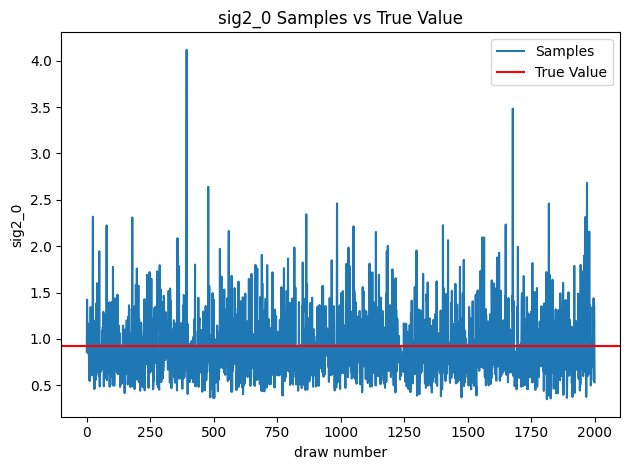

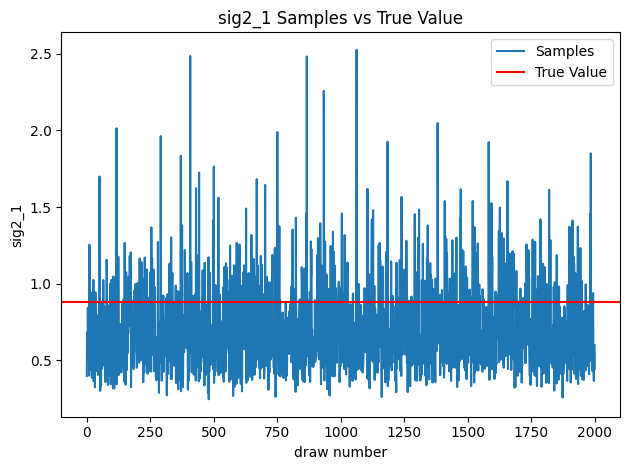

,True Value,Sample Mean
sig2_0,0.927109,0.910024
sig2_1,0.882642,0.697452


In [112]:
sampler = CycloneSampler(
    W=W_sim,
    X=X,
    basins=basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=2
)
params_to_include = ["sig2"]
sampler.partial_sample(2000, params_to_include, init_state=real_params)
table = comparison_table(sampler, real_params_dict, params_to_include=params_to_include, burnin=200)
plot_traces(params_to_include, real_params_dict, sampler)
table

## Test Lam
### Result: lam sampler is not performing as expected, some values are not recovered.

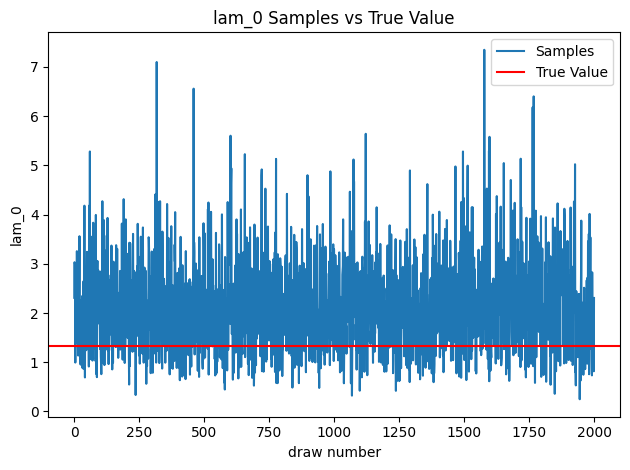

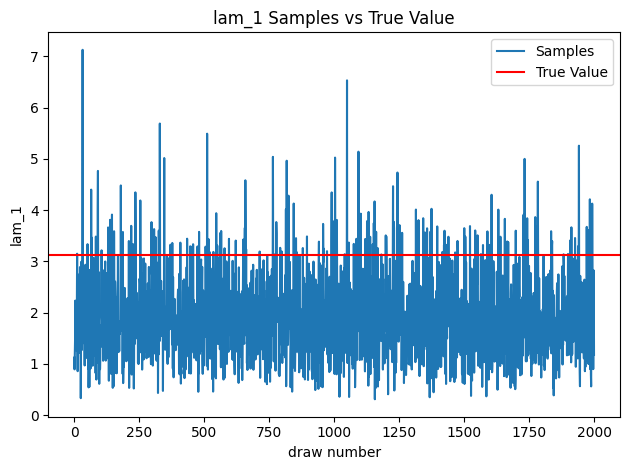

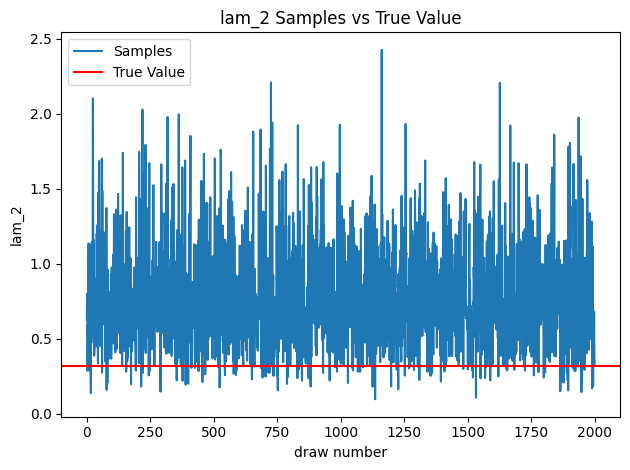

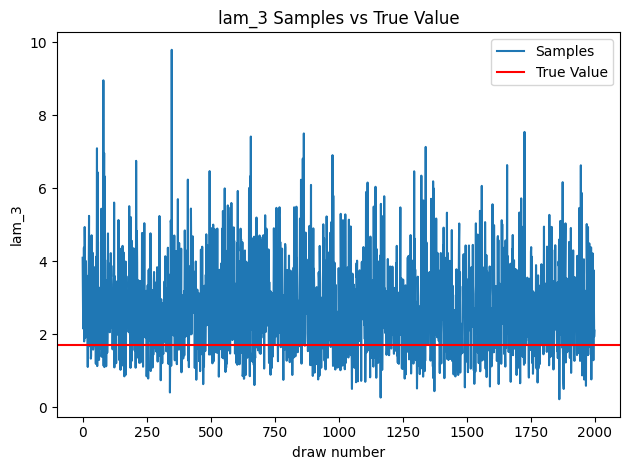

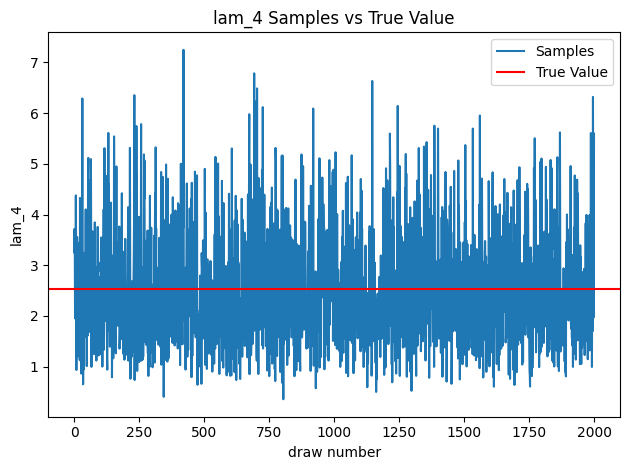

,True Value,Sample Mean
lam_0,1.329937,2.110158
lam_1,3.131542,1.918393
lam_2,0.316954,0.765939
lam_3,1.706082,2.681693
lam_4,2.536532,2.490539


In [113]:
sampler = CycloneSampler(
    W=W_sim,
    X=X,
    basins=basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=2
)
params_to_include = ["lam"]
sampler.partial_sample(2000, params_to_include, init_state=real_params)
table = comparison_table(sampler, real_params_dict, params_to_include=params_to_include, burnin=200)
plot_traces(params_to_include, real_params_dict, sampler)
table

## Test Beta
### Result: beta sampler is not performing as expected, some values are not recovered.

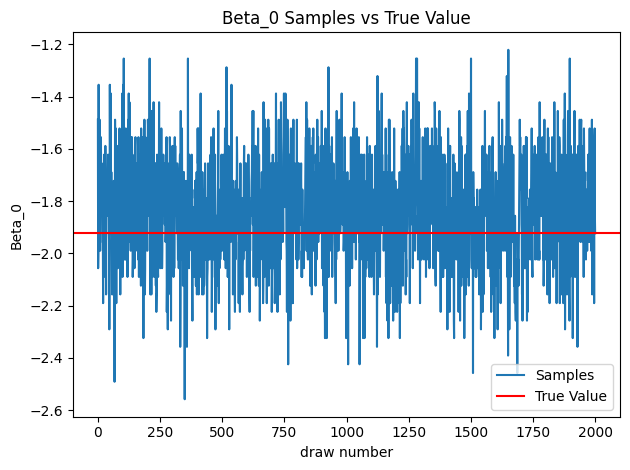

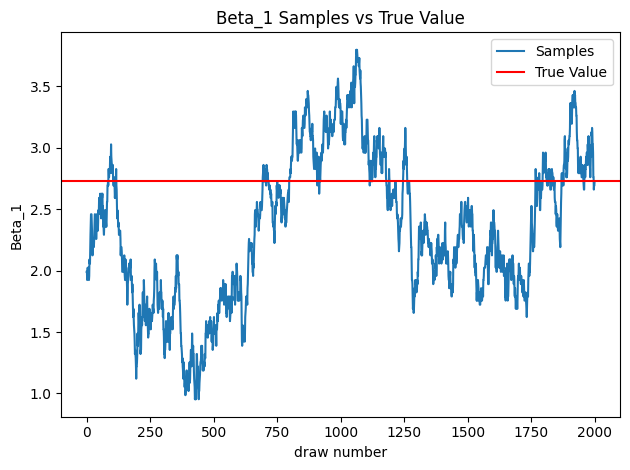

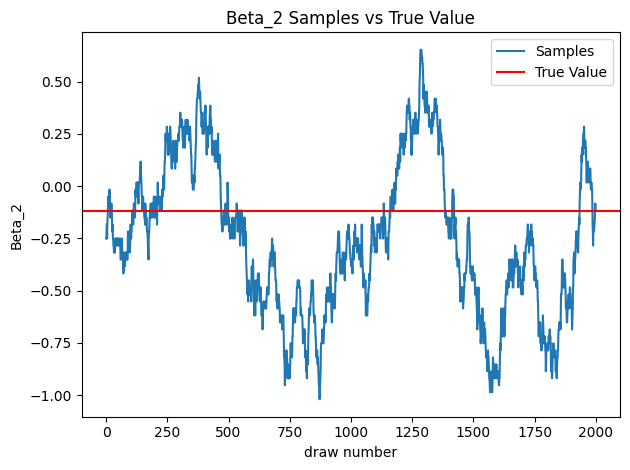

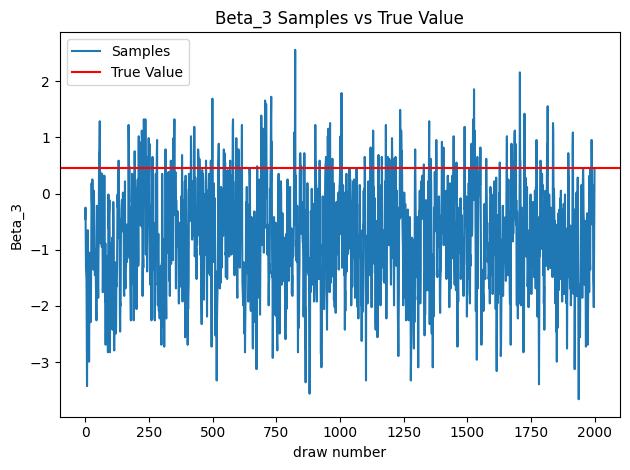

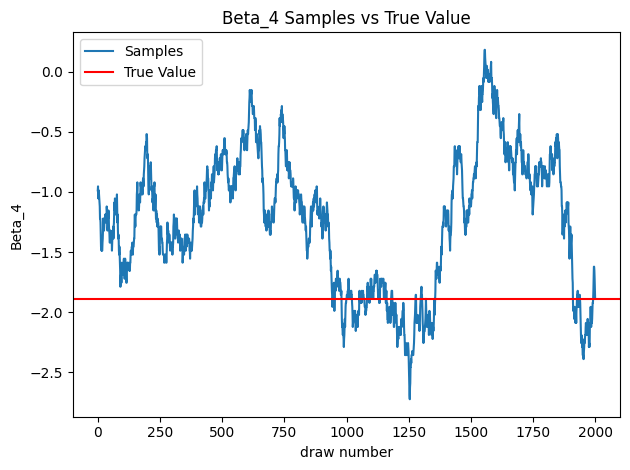

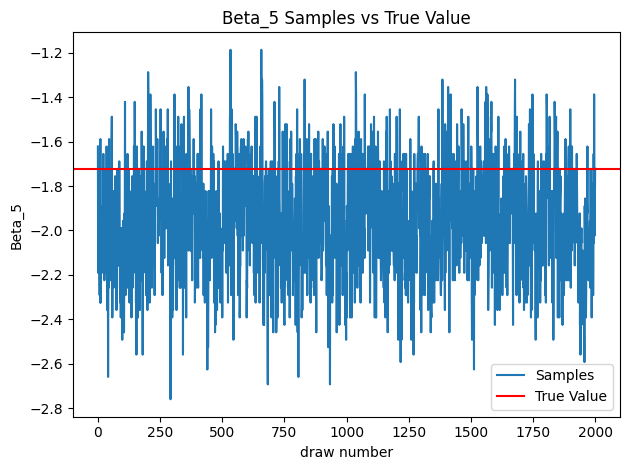

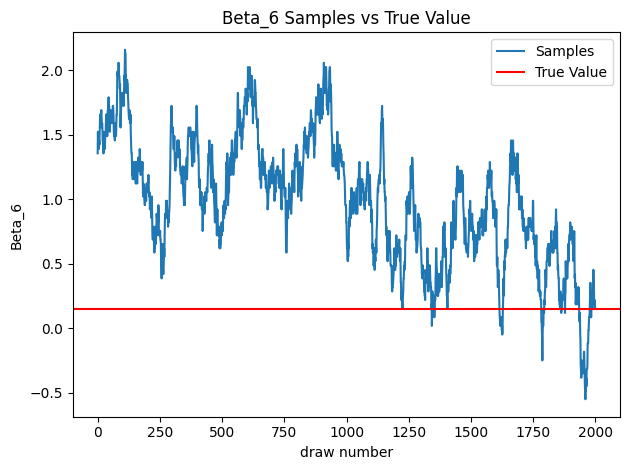

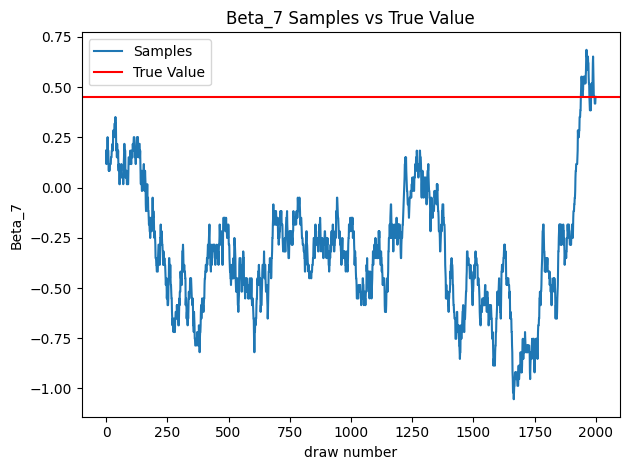

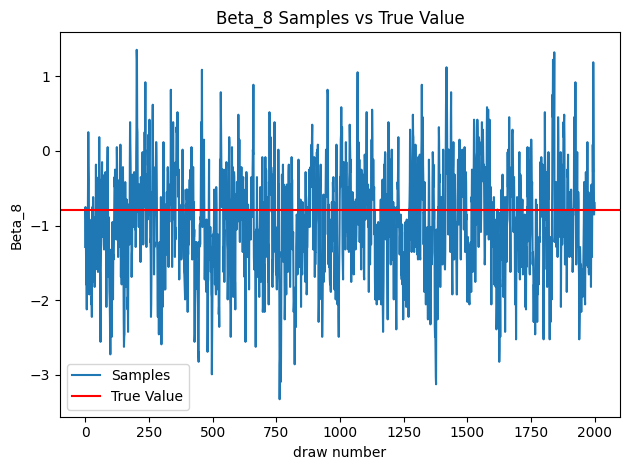

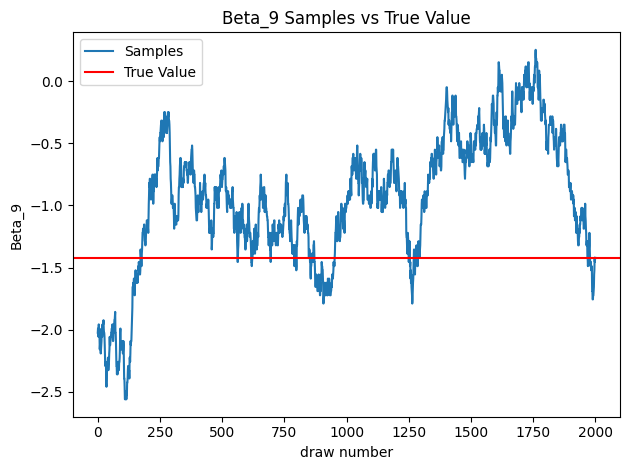

,True Value,Sample Mean
Beta_0,-1.923077,-1.843311
Beta_1,2.725753,2.349517
Beta_2,-0.117057,-0.268711
Beta_3,0.451505,-0.764474
Beta_4,-1.889632,-1.233129
Beta_5,-1.722408,-1.949554
Beta_6,0.150502,0.929078
Beta_7,0.451505,-0.357952
Beta_8,-0.785953,-0.951394
Beta_9,-1.421405,-0.833816


In [114]:
sampler = CycloneSampler(
    W=W_sim,
    X=X,
    basins=basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=2
)
params_to_include = ["Beta"]
sampler.partial_sample(2000, params_to_include, init_state=real_params)
table = comparison_table(sampler, real_params_dict, params_to_include=params_to_include, burnin=200)
# this plot trace function doesnt work for the matrix one yet my bad
plot_traces(params_to_include, real_params_dict, sampler)
table

## Test Alpha
### Result: alpha sampler is not quite performing as expected, it tends to be higher than the true value?

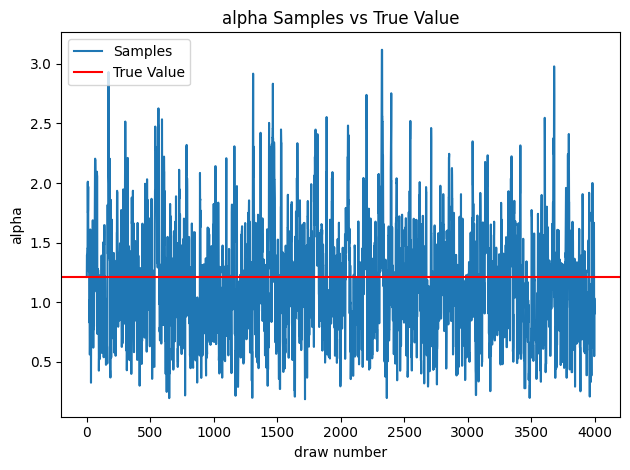

,True Value,Sample Mean
alpha,1.211794,1.134729


In [115]:
sampler = CycloneSampler(
    W=W_sim,
    X=X,
    basins=basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=2
)
params_to_include = ["alpha"]
sampler.partial_sample(4000, params_to_include, init_state=real_params)
table = comparison_table(sampler, real_params_dict, params_to_include=params_to_include, burnin=200)
plot_traces(params_to_include, real_params_dict, sampler)
table

## Test Gamma
### Result: gamma sampler is not quite performing as expected, it tends to be higher than the true value?

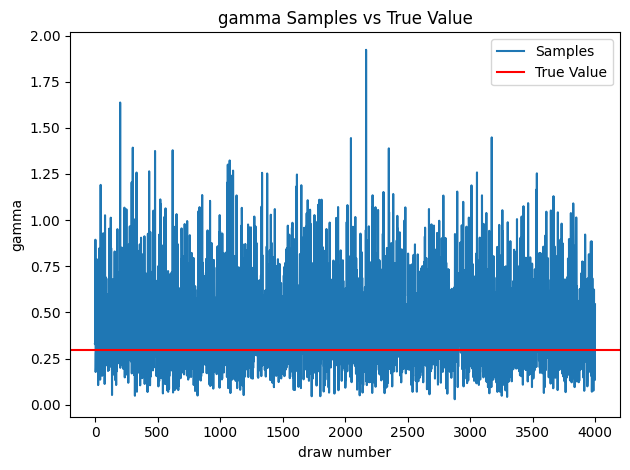

,True Value,Sample Mean
gamma,0.296544,0.442652


In [116]:
sampler = CycloneSampler(
    W=W_sim,
    X=X,
    basins=basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=2
)
params_to_include = ["gamma"]
sampler.partial_sample(4000, params_to_include, init_state=real_params)
table = comparison_table(sampler, real_params_dict, params_to_include=params_to_include, burnin=200)
plot_traces(params_to_include, real_params_dict, sampler)
table

## Test tau2
### Result: tau2 sampler is not performing as expected, some values are not recovered

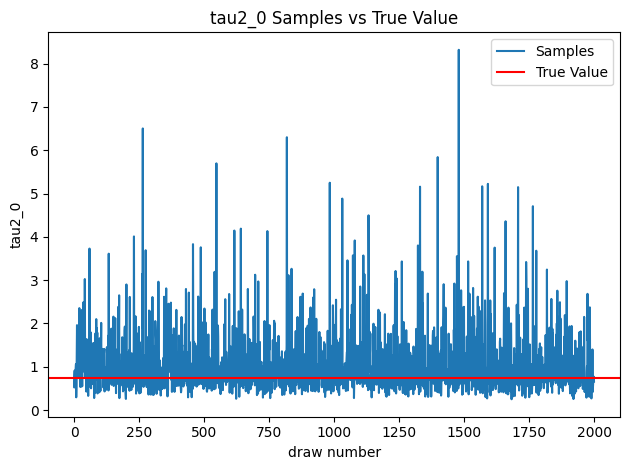

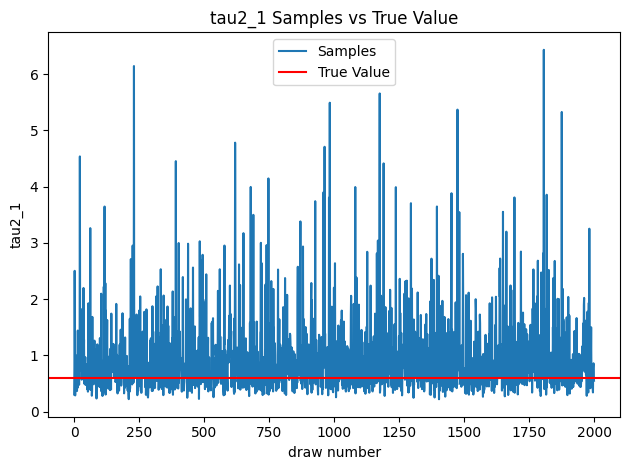

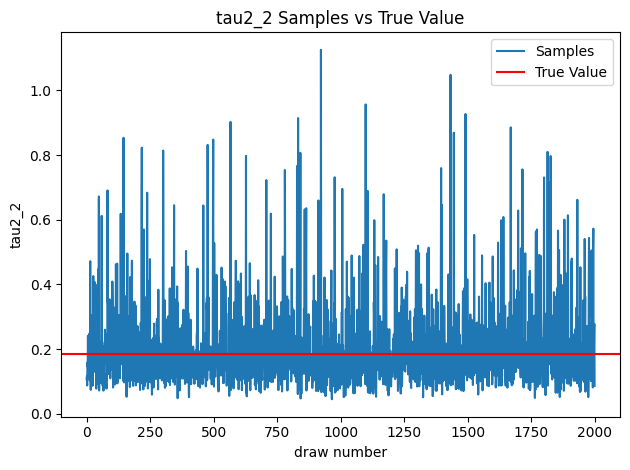

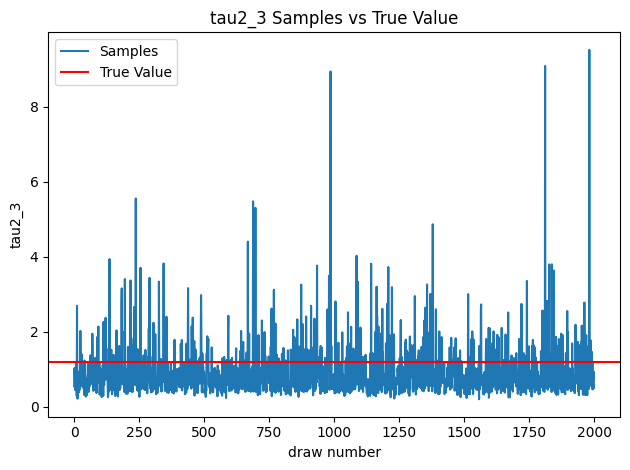

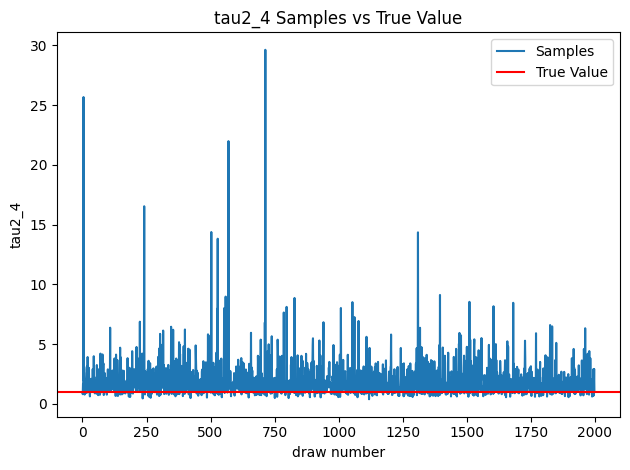

,True Value,Sample Mean
tau2_0,0.736118,1.075014
tau2_1,0.607801,0.957299
tau2_2,0.183673,0.205259
tau2_3,1.194915,0.921412
tau2_4,0.994039,1.962606


In [117]:
sampler = CycloneSampler(
    W=W_sim,
    X=X,
    basins=basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=2
)
params_to_include = ["tau2"]
sampler.partial_sample(2000, params_to_include, init_state=real_params)
table = comparison_table(sampler, real_params_dict, params_to_include=params_to_include, burnin=200)
plot_traces(params_to_include, real_params_dict, sampler)
table

## Test nu
### Result: nu sampler is not performing as expected, some values are not recovered

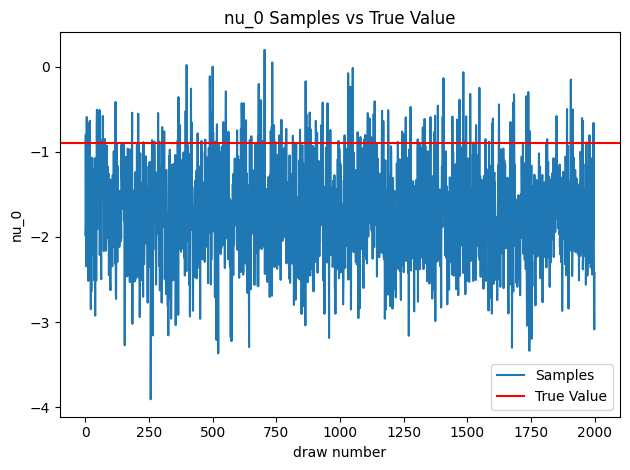

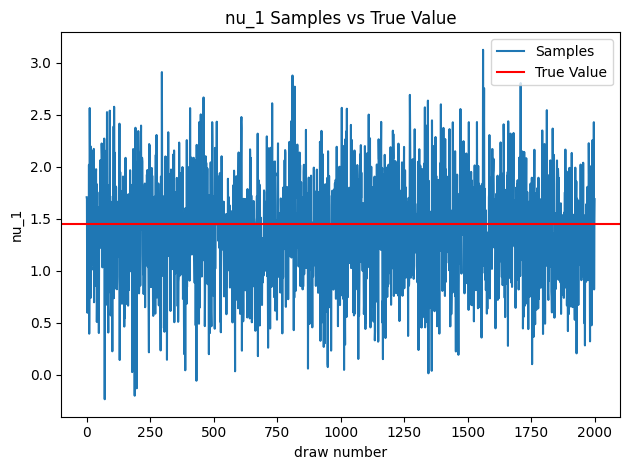

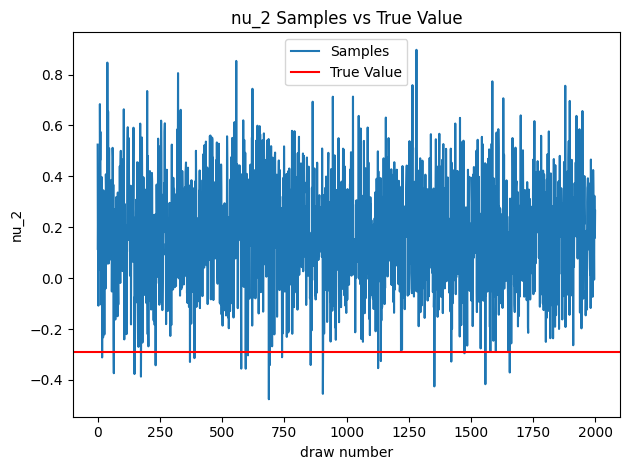

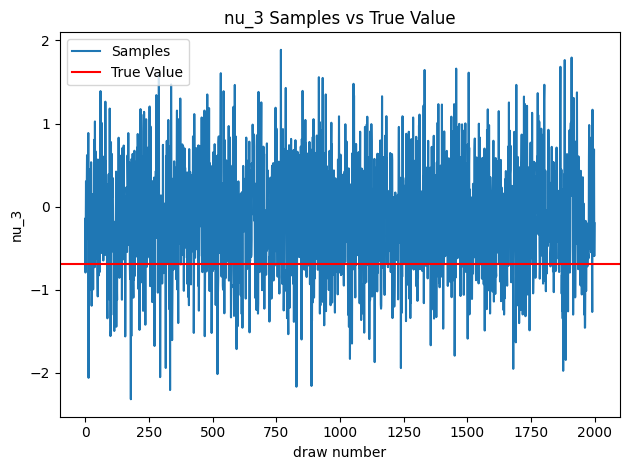

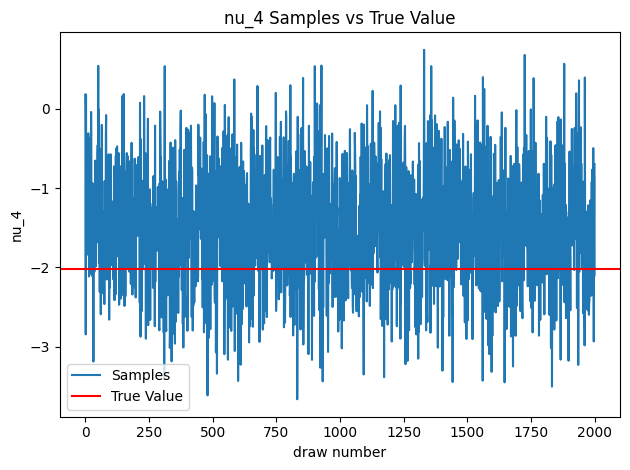

,True Value,Sample Mean
nu_0,-0.891611,-1.693480
nu_1,1.453795,1.372674
nu_2,-0.290198,0.172517
nu_3,-0.687179,-0.134365
nu_4,-2.019803,-1.486069


In [118]:
sampler = CycloneSampler(
    W=W_sim,
    X=X,
    basins=basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=2
)
params_to_include = ["nu"]
sampler.partial_sample(2000, params_to_include, init_state=real_params)
table = comparison_table(sampler, real_params_dict, params_to_include=params_to_include, burnin=200)
plot_traces(params_to_include, real_params_dict, sampler)
table